In [1]:
#==============================================================================
# STEP 0 — SELECT A COMPANY
# ==============================================================================

# Selected Company: Lululemon Athletica Inc. (Ticker: LULU)
# Assigned Geographic Group: Group 2 - Canada

# Justification:
# For this deep dive, I selected Lululemon Athletica Inc. (LULU). 
# First, it complies with my assigned geographic group (Canada). 
# Second, it allows me to build on my Homework 1 analysis since LULU belongs 
# to the Consumer Cyclical sector (specifically the Apparel Retail industry).
# LULU holds a leading industry position as an important player with a solid 
# market cap (~$15.2 Billion) and demonstrates strong historical profitability 
# with a premium profit margin of 14.22% and a high ROE of 34.01%. This profile 
# perfectly aligns with the high-profitability dynamics explored in my Homework 1 
# for this sector, making it an excellent candidate for a fundamental analysis.

selected_ticker = "LULU"

In [2]:
# ==============================================================================
# STEP 1 — DATA PREPARATION
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset and keep only the variables needed for the analysis
df = pd.read_csv('Symbol_Info_extended.csv')

required_columns = [
    'symbol', 'company_name', 'sector', 'industry', 'country', 'market_cap',
    'return_on_assets', 'return_on_equity', 'profit_margins',
    'pe_trailing', 'price_to_book', 'revenue_growth', 'debt_to_equity', 'free_cashflow'
]
df_working = df[required_columns].copy()

# Clean data by removing infinities and filtering out non-positive market caps
df_working = df_working.replace([np.inf, -np.inf], np.nan)
df_working = df_working[df_working['market_cap'] > 0]

# Set negative P/E and P/B to NaN to ensure fair comparison
df_working.loc[df_working['pe_trailing'] <= 0, 'pe_trailing'] = np.nan
df_working.loc[df_working['price_to_book'] <= 0, 'price_to_book'] = np.nan

# Check dimensions and look at Lululemon profile
print("Data preparation complete successfully!")
print(f"Total companies available for analysis: {len(df_working)}")
print("\nTarget Company Data Summary:")
print(df_working[df_working['symbol'] == selected_ticker].T)

Data preparation complete successfully!
Total companies available for analysis: 2970

Target Company Data Summary:
                                      1674
symbol                                LULU
company_name      lululemon athletica inc.
sector                   Consumer Cyclical
industry                    Apparel Retail
country                             Canada
market_cap                   15204484096.0
return_on_assets                   0.17206
return_on_equity                   0.34013
profit_margins                     0.14224
pe_trailing                       9.591251
price_to_book                     2.986007
revenue_growth                       0.008
debt_to_equity                      36.245
free_cashflow                  824078400.0


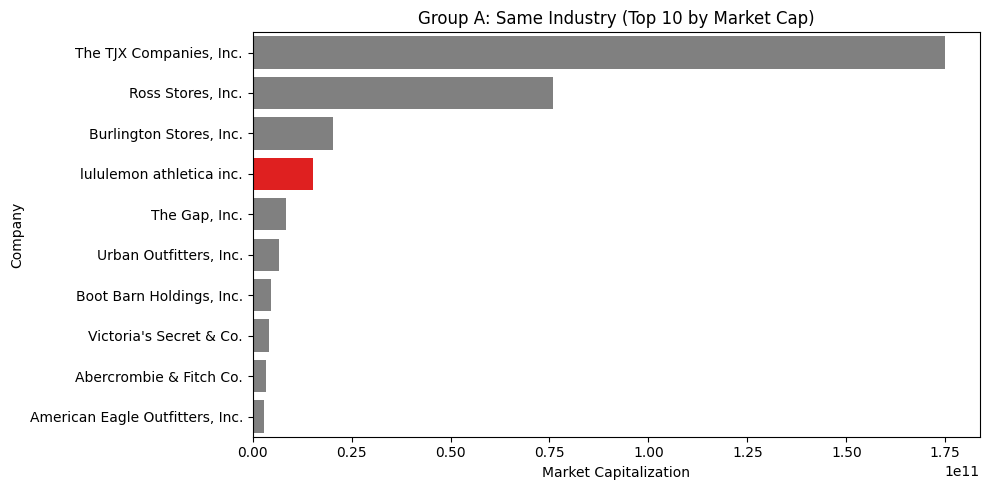

In [3]:
# ==============================================================================
# STEP 2: BUILD PEER GROUPS
# ==============================================================================

# Extract Lululemon's specific values for filtering
lulu_row = df_working[df_working['symbol'] == selected_ticker].iloc[0]
lulu_industry = lulu_row['industry']
lulu_country = lulu_row['country']
lulu_mc = lulu_row['market_cap']

# Group A: Same Industry
group_a_all = df_working[df_working['industry'] == lulu_industry].sort_values('market_cap', ascending=False)
group_a = group_a_all.head(10).copy()

# Add Lululemon if it didn't make the top 10
if selected_ticker not in group_a['symbol'].values:
    lulu_df = group_a_all[group_a_all['symbol'] == selected_ticker]
    group_a = pd.concat([group_a, lulu_df])

# Group B: Same Geographic Group
group_b_all = df_working[df_working['country'] == lulu_country].sort_values('market_cap', ascending=False)
group_b = group_b_all.head(10).copy()

if selected_ticker not in group_b['symbol'].values:
    lulu_df = group_b_all[group_b_all['symbol'] == selected_ticker]
    group_b = pd.concat([group_b, lulu_df])


# Group C: Closest Market Capitalization
# Calculate absolute distance to Lululemon's market cap
df_working['mc_distance'] = abs(df_working['market_cap'] - lulu_mc)
group_c = df_working.sort_values('mc_distance').head(10).copy()

# Visualization (Example on Group A to show compliance with guidelines)

display_labels = []
colors = []

for index, row in group_a.iterrows():
    # Fallback to symbol if company name is missing
    if pd.isna(row['company_name']):
        display_labels.append(row['symbol'])
    else:
        display_labels.append(row['company_name'])
        
    # Highlight the target company
    if row['symbol'] == selected_ticker:
        colors.append('red')
    else:
        colors.append('gray')

plt.figure(figsize=(10, 5))
sns.barplot(x=group_a['market_cap'], y=display_labels, hue=display_labels, palette=colors, legend=False)

plt.title('Group A: Same Industry (Top 10 by Market Cap)')
plt.xlabel('Market Capitalization')
plt.ylabel('Company')
plt.tight_layout()
plt.show()


ANALYZING METRIC: PROFIT_MARGINS


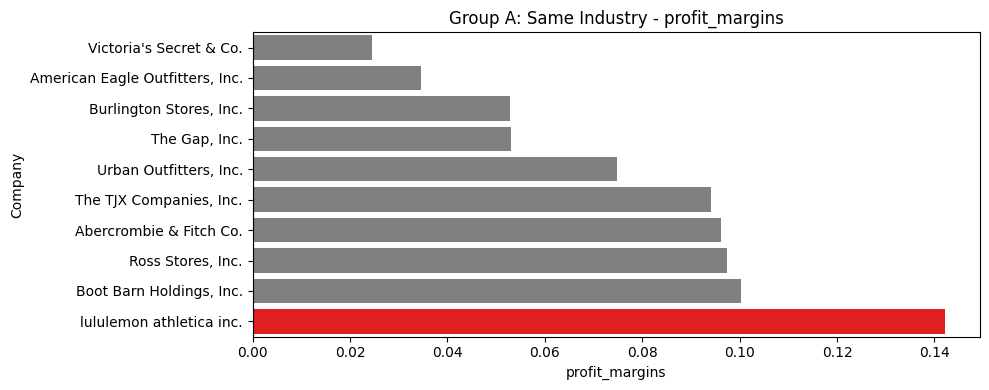

> Group A: Same Industry Median: 0.0844 | Lululemon: 0.1422


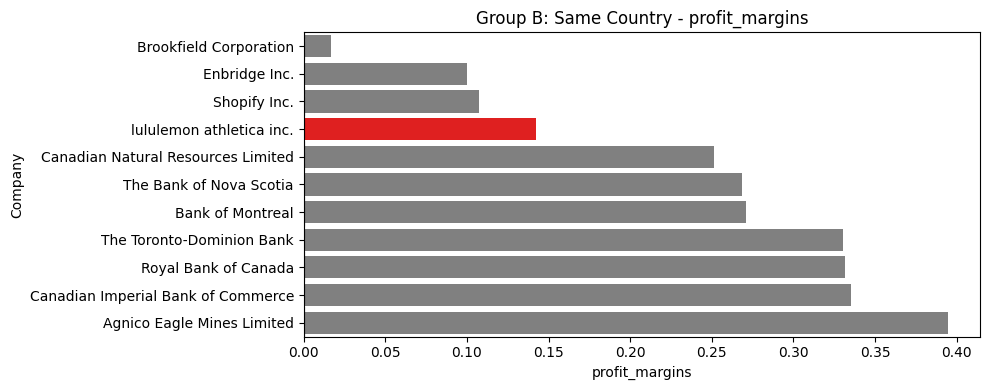

> Group B: Same Country Median: 0.2685 | Lululemon: 0.1422


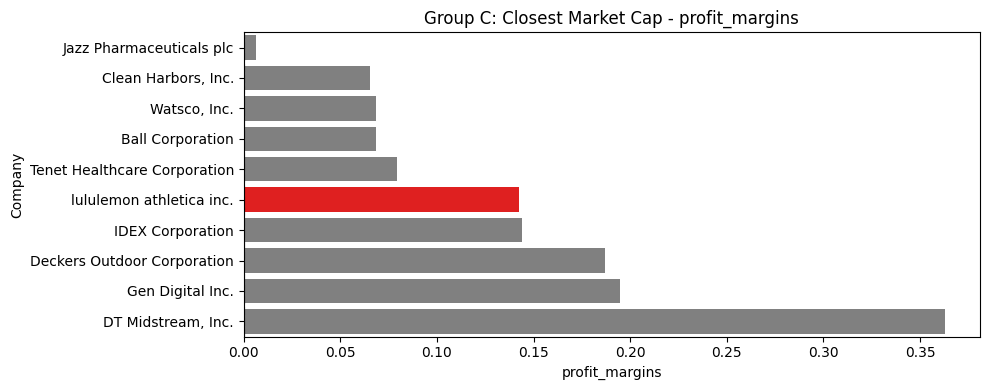

> Group C: Closest Market Cap Median: 0.1108 | Lululemon: 0.1422

ANALYZING METRIC: RETURN_ON_EQUITY


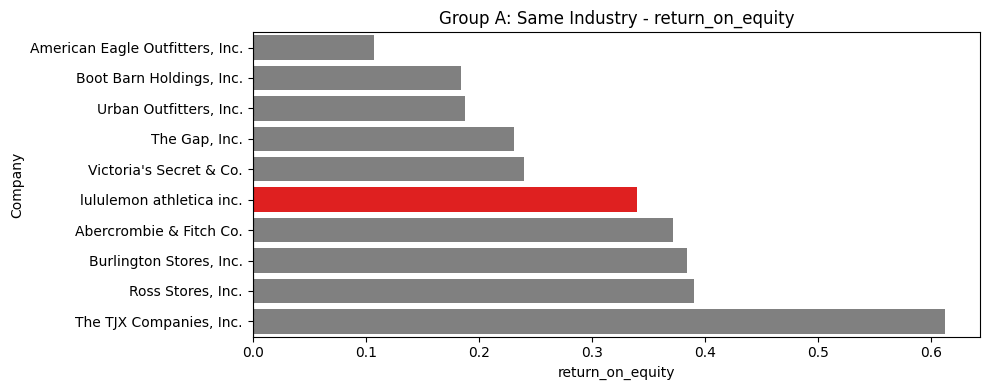

> Group A: Same Industry Median: 0.2901 | Lululemon: 0.3401


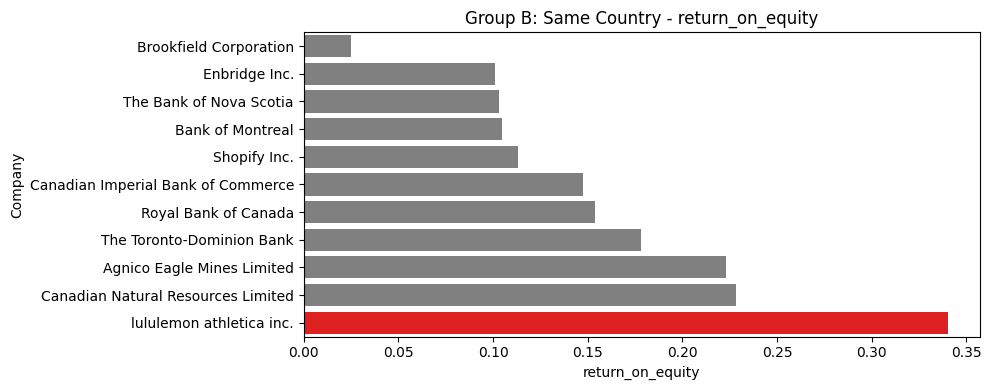

> Group B: Same Country Median: 0.1475 | Lululemon: 0.3401


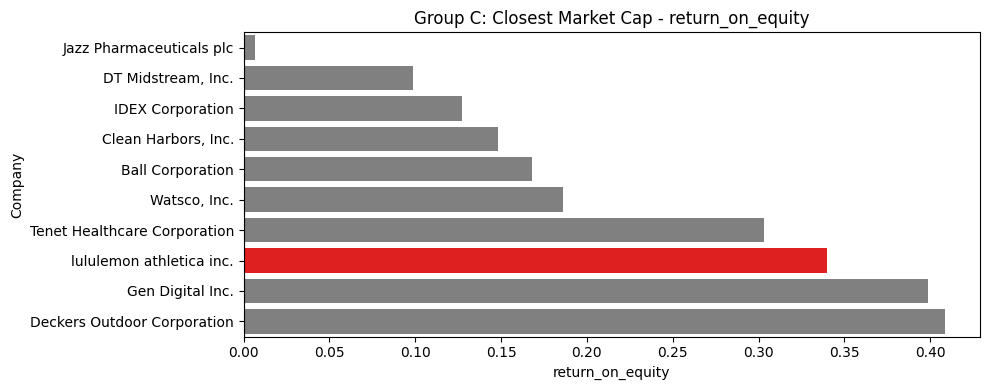

> Group C: Closest Market Cap Median: 0.1769 | Lululemon: 0.3401


In [4]:
# ==============================================================================
# STEP 3: BUSINESS QUESTION 1 - IS THE COMPANY PROFITABLE?
# ==============================================================================

# We select profit margins and return on equity (ROE)
metrics_to_test = ['profit_margins', 'return_on_equity']

# We put our 3 groups in a list to easily loop through them
peer_groups = [
    ('Group A: Same Industry', group_a),
    ('Group B: Same Country', group_b),
    ('Group C: Closest Market Cap', group_c)
]

for metric in metrics_to_test:
    print(f"\n{'='*50}")
    print(f"ANALYZING METRIC: {metric.upper()}")
    print(f"{'='*50}")
    
    for group_name, group_df in peer_groups:
        
        # Clean missing values for this metric
        clean_df = group_df.dropna(subset=[metric]).copy()
        
        # Sort the data so the chart looks organized
        clean_df = clean_df.sort_values(by=metric, ascending=True)
        
        display_labels = []
        colors = []
        
        for index, row in clean_df.iterrows():
            if pd.isna(row['company_name']):
                display_labels.append(row['symbol'])
            else:
                display_labels.append(row['company_name'])
                
            if row['symbol'] == selected_ticker:
                colors.append('red')
            else:
                colors.append('gray')
                
        # Plotting the chart
        plt.figure(figsize=(10, 4))
        sns.barplot(x=clean_df[metric], y=display_labels, hue=display_labels, palette=colors, legend=False)
        
        plt.title(f'{group_name} - {metric}')
        plt.xlabel(metric)
        plt.ylabel('Company')
        
        # Add the zero line
        plt.axvline(x=0, color='black', linestyle='--')
        
        plt.tight_layout()
        plt.show()
        
        # Calculate and print medians for the written analysis
        median_val = clean_df[metric].median()
        
        # Safely get Lululemon's value if it's not missing
        lulu_data = clean_df[clean_df['symbol'] == selected_ticker]
        if not lulu_data.empty:
            lulu_val = lulu_data[metric].values[0]
            print(f"> {group_name} Median: {median_val:.4f} | Lululemon: {lulu_val:.4f}")
        else:
            print(f"> Lululemon has missing data for {metric} in {group_name}")

Interpretation: Is Lululemon Profitable?

Looking at the data, Lululemon is definitely a profitable company, though its standing changes noticeably depending on which peer group we compare it to.

Starting with profit margins, the company sits at a very healthy 14.2%. This is excellent within its direct industry, where it ranks 1st and easily beats the 8.4% median. However, when we zoom out to other benchmarks, its performance is closer to average. It ranks 5th compared to similar-sized companies (median 11.1%) and 8th within its Canadian peers (who have a much higher median of 26.8%).

For Return on Equity (ROE), the situation is almost the opposite, showing that the two metrics are not perfectly consistent with each other across all groups. With a strong ROE of 34.0%, Lululemon takes the 1st spot among its Country peers (median 14.7%) and ranks a solid 3rd against companies with a similar market cap (median 17.7%). But surprisingly, within its own industry, it only ranks 5th (median 29.0%). This means that while Lululemon is incredibly efficient at generating profit from its sales (margins), a few of its direct competitors are actually squeezing even higher returns out of their shareholders' equity.

Overall, Lululemon is a highly profitable and well-run business. It consistently generates strong net income, even if it doesn't top every single chart across the board.


ANALYZING VALUATION METRIC: PE_TRAILING


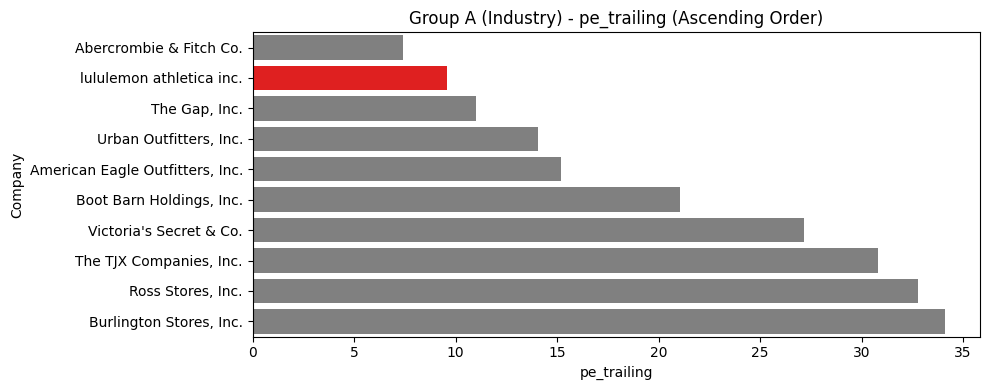

> Group A Median: 18.10 | Lululemon: 9.59

ANALYZING VALUATION METRIC: PRICE_TO_BOOK


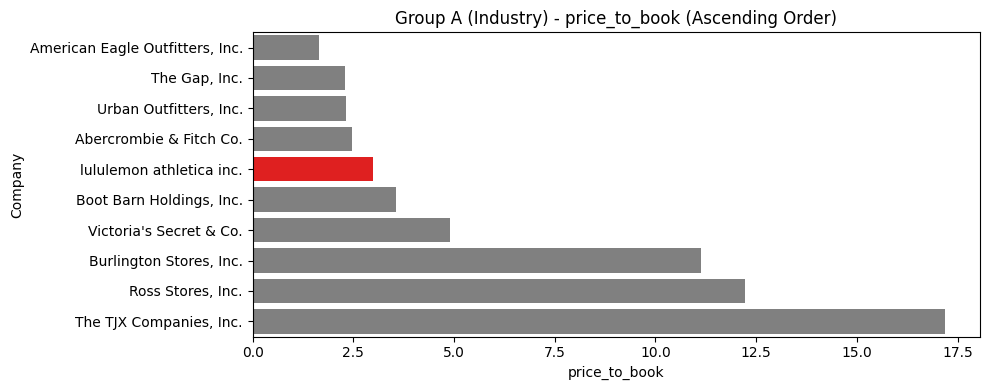

> Group A Median: 3.27 | Lululemon: 2.99


In [5]:
# ==============================================================================
# STEP 4: BUSINESS QUESTION 2 - IS THE COMPANY EXPENSIVE OR CHEAP?
# ==============================================================================

# We only focus on Group A (Same Industry) for valuation
valuation_metrics = ['pe_trailing', 'price_to_book']

for metric in valuation_metrics:
    print(f"\n{'='*50}")
    print(f"ANALYZING VALUATION METRIC: {metric.upper()}")
    print(f"{'='*50}")
    
    # Clean the data: Values <= 0 were already set to NaN in Step 1. 
    # We just drop the NaNs for this specific metric to sort and plot cleanly.
    clean_df = group_a.dropna(subset=[metric]).copy()
    
    # Sort charts in ascending order (Cheapest at the top, most expensive at bottom)
    clean_df = clean_df.sort_values(by=metric, ascending=True)
    
    # Prepare labels and colors 
    display_labels = []
    colors = []
    
    for index, row in clean_df.iterrows():
        if pd.isna(row['company_name']):
            display_labels.append(row['symbol'])
        else:
            display_labels.append(row['company_name'])
            
        if row['symbol'] == selected_ticker:
            colors.append('red')
        else:
            colors.append('gray')
            
    #  Plotting the chart
    plt.figure(figsize=(10, 4))
    sns.barplot(x=clean_df[metric], y=display_labels, hue=display_labels, palette=colors, legend=False)
    
    plt.title(f'Group A (Industry) - {metric} (Ascending Order)')
    plt.xlabel(metric)
    plt.ylabel('Company')
    plt.tight_layout()
    plt.show()
    
    # Calculate and print Medians for the written analysis
    if not clean_df.empty:
        median_val = clean_df[metric].median()
        
        lulu_data = clean_df[clean_df['symbol'] == selected_ticker]
        if not lulu_data.empty:
            lulu_val = lulu_data[metric].values[0]
            print(f"> Group A Median: {median_val:.2f} | Lululemon: {lulu_val:.2f}")
        else:
            print(f"> Lululemon has missing data for {metric}")

Interpretation: Is Lululemon Expensive, Cheap, or Fairly Valued?

Looking at the valuation metrics compared to its direct industry (Group A), Lululemon actually appears quite cheap right now, trading at a noticeable discount.

If we look at the charts, Lululemon is visibly positioned in the cheaper half. For its Price-to-Earnings (pe_trailing) ratio, the company sits right near the top in the 2nd position with a multiple of just 9.59, which is well below the industry median of 18.10. The Price-to-Book ratio tells something similar: Lululemon ranks 5th with a multiple of 2.99, again staying under the group median of 3.27.

In the retail sector, seeing a stock priced this low can sometimes be a warning sign. Often, companies at the very top of these ascending valuation charts are "value traps", meaning they are cheap simply because they have terrible margins or weak fundamentals.

However, Lululemon is a major exception to this rule. As we established in Step 3, the company is highly profitable, with the highest profit margin in its group and a massive 34.0% ROE. Because of this, its low valuation multiples clearly aren't reflecting a struggling business. Instead, it looks like a genuine market opportunity: the market is currently undervaluing a highly efficient company compared to peers who perform much worse.


ANALYZING METRIC: REVENUE_GROWTH


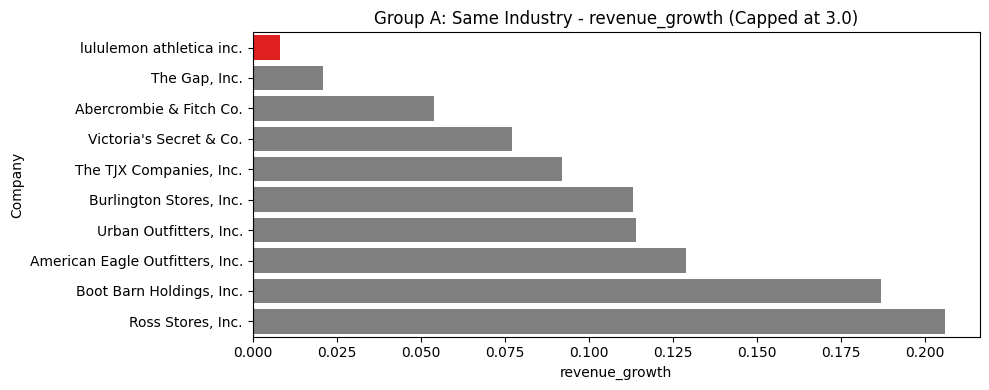

> Group A: Same Industry Median: 0.1025 | Lululemon: 0.0080

ANALYZING METRIC: REVENUE_GROWTH


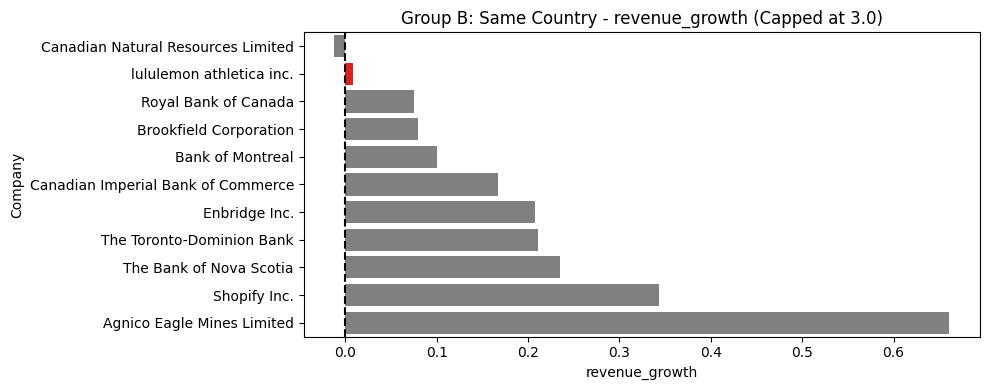

> Group B: Same Country Median: 0.1670 | Lululemon: 0.0080

ANALYZING METRIC: REVENUE_GROWTH


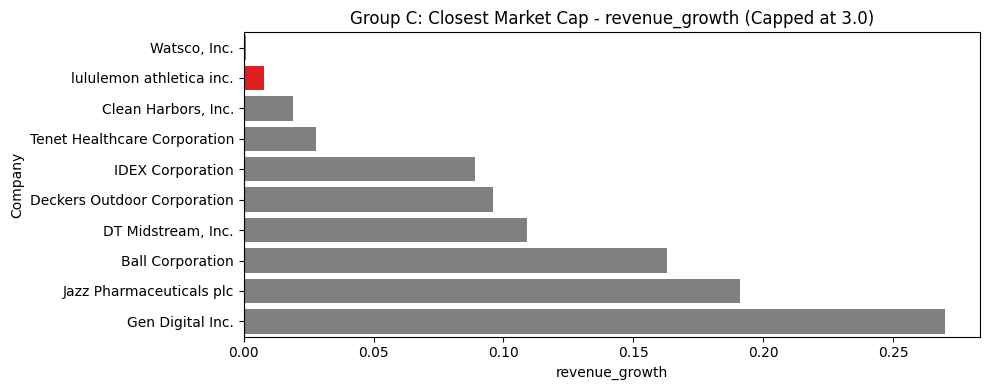

> Group C: Closest Market Cap Median: 0.0925 | Lululemon: 0.0080


In [6]:
# ==============================================================================
# STEP 5: BUSINESS QUESTION 3 - IS THE COMPANY GROWING?
# ==============================================================================

metric = 'revenue_growth'

# We set a cap to avoid outliers distorting the chart scale (> 300% growth)
cap_value = 3.0 

for group_name, group_df in peer_groups:
    print(f"\n{'='*50}")
    print(f"ANALYZING METRIC: {metric.upper()}")
    print(f"{'='*50}")
    
    # Clean missing values for this metric only
    clean_df = group_df.dropna(subset=[metric]).copy()
    
    # Apply the cap for outliers (Any value > 3.0 becomes 3.0)
    clean_df[metric] = clean_df[metric].clip(upper=cap_value)
    
    # Sort the data
    clean_df = clean_df.sort_values(by=metric, ascending=True)
    
    # Prepare labels and colors
    display_labels = []
    colors = []
    
    for index, row in clean_df.iterrows():
        if pd.isna(row['company_name']):
            display_labels.append(row['symbol'])
        else:
            display_labels.append(row['company_name'])
            
        if row['symbol'] == selected_ticker:
            colors.append('red')
        else:
            colors.append('gray')
            
    # Plotting the chart
    plt.figure(figsize=(10, 4))
    sns.barplot(x=clean_df[metric], y=display_labels, hue=display_labels, palette=colors, legend=False)
    
    plt.title(f'{group_name} - {metric} (Capped at {cap_value})')
    plt.xlabel(metric)
    plt.ylabel('Company')
    
    # Add the zero line to easily spot negative growth (revenue decline)
    plt.axvline(x=0, color='black', linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate and print medians 
    # We use the un-capped raw data to ensure the median calculation is mathematically exact
    raw_clean_df = group_df.dropna(subset=[metric])
    if not raw_clean_df.empty:
        median_val = raw_clean_df[metric].median()
        
        lulu_data = raw_clean_df[raw_clean_df['symbol'] == selected_ticker]
        if not lulu_data.empty:
            lulu_val = lulu_data[metric].values[0]
            print(f"> {group_name} Median: {median_val:.4f} | Lululemon: {lulu_val:.4f}")
        else:
            print(f"> Lululemon has missing data for {metric} in {group_name}")

Interpretation: Is Lululemon Growing?

Looking at the revenue growth charts across the three peer groups, Lululemon is still growing, but at a noticeably slower pace than its competitors.

On the bright side, the company's growth rate is positive at 0.80% (0.0080). This means that sales are still going up and the business is not shrinking. However, when we compare that 0.80% to the rest of the market, Lululemon is clearly lagging behind in terms of speed. For context, the median growth in its direct industry (Group A) is much higher at 10.25%. The gap is even wider when looking at its Canadian peers (Group B median: 16.70%) or companies with a similar market cap (Group C median: 9.25%).

This slowdown in growth is actually the missing puzzle piece that explains the "cheap" valuation we saw in Step 4. Even though Lululemon is highly profitable with excellent margins (as seen in Step 3), the stock market is always looking ahead. Investors are pricing the stock lower, giving it smaller P/E and P/B multiples, simply because the company is entering a more mature phase where revenue doesn't expand as rapidly anymore. So, its low price tag isn't a red flag about bad business fundamentals, it's just the market's logical adjustment to a slower and more stable growth rate.


ANALYZING METRIC: DEBT_TO_EQUITY


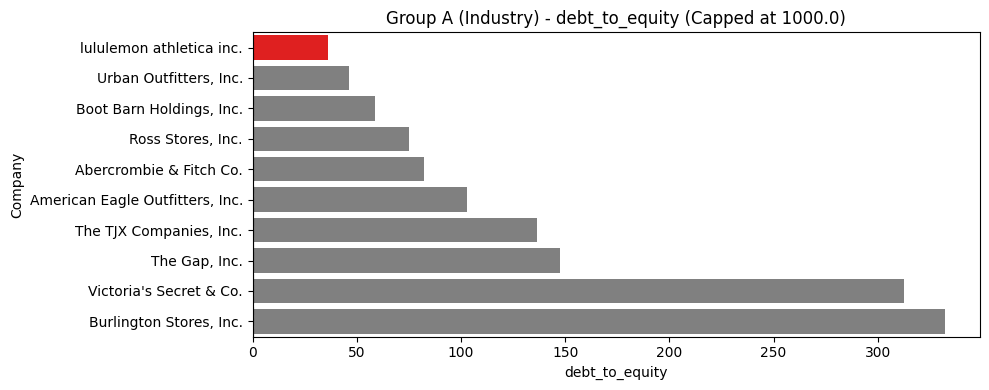

> Group A Median: 92.62 | Lululemon: 36.24

ANALYZING METRIC: FREE_CASHFLOW


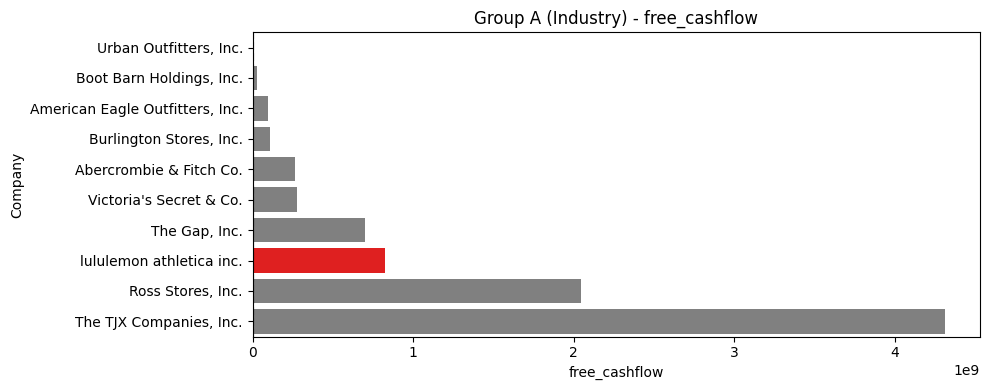

> Group A Median: 269497928.00 | Lululemon: 824078400.00


In [7]:
# ==============================================================================
# STEP 6: BUSINESS QUESTION 4 - IS THE COMPANY FINANCIALLY SOLID?
# ==============================================================================

metrics = ['debt_to_equity', 'free_cashflow']

# Set a cap for debt to avoid extreme outliers
cap_debt = 1000.0

for metric in metrics:
    print(f"\n{'='*50}")
    print(f"ANALYZING METRIC: {metric.upper()}")
    print(f"{'='*50}")
    
    # Clean missing values
    clean_df = group_a.dropna(subset=[metric]).copy()
    
    # Apply cap if the metric is debt_to_equity
    if metric == 'debt_to_equity':
        clean_df[metric] = clean_df[metric].clip(upper=cap_debt)
        
    # Sort the data
    clean_df = clean_df.sort_values(by=metric, ascending=True)
    
    # Prepare labels and colors
    display_labels = []
    colors = []
    
    for index, row in clean_df.iterrows():
        if pd.isna(row['company_name']):
            display_labels.append(row['symbol'])
        else:
            display_labels.append(row['company_name'])
            
        if row['symbol'] == selected_ticker:
            colors.append('red')
        else:
            colors.append('gray')
            
    # Plotting the chart
    plt.figure(figsize=(10, 4))
    sns.barplot(x=clean_df[metric], y=display_labels, hue=display_labels, palette=colors, legend=False)
    
    title_suffix = f" (Capped at {cap_debt})" if metric == 'debt_to_equity' else ""
    plt.title(f'Group A (Industry) - {metric}{title_suffix}')
    plt.xlabel(metric)
    plt.ylabel('Company')
    
    # Add vertical line for 0 (useful for seeing who burns cash or has no debt)
    plt.axvline(x=0, color='black', linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate and print medians
    raw_clean_df = group_a.dropna(subset=[metric])
    if not raw_clean_df.empty:
        median_val = raw_clean_df[metric].median()
        
        lulu_data = raw_clean_df[raw_clean_df['symbol'] == selected_ticker]
        if not lulu_data.empty:
            lulu_val = lulu_data[metric].values[0]
            print(f"> Group A Median: {median_val:.2f} | Lululemon: {lulu_val:.2f}")

Interpretation: Is Lululemon Financially Solid?

Looking at its capital structure and cash generation compared to its direct industry (Group A), Lululemon clearly has a very solid financial profile.

When looking at debt reliance (debt_to_equity), Lululemon operates with very low debt. The chart shows a ratio of 36.24%, placing it at the very top of its peer group. Not only is this well below the industry median of 92.62%, but it also easily beats the 50% threshold considered as a "strong signal" in the reference table. By keeping such a low debt load, Lululemon shows minimal financial risk and a much safer balance sheet than its more heavily leveraged competitors.

On the cash generation side (free_cashflow), the company ranks 3rd best in its industry. It generates over 824 million in positive free cash flow, comfortably beating the group median of roughly 269 million. This proves that Lululemon easily avoids the negative free cash flow zone, meaning the core business makes more than enough money to self-fund its operations and future growth without needing external financing.

Overall, Lululemon's financial health is undeniably strong. Combining low debt with massive positive cash flow makes the company highly resilient to economic slowdowns or interest rate changes, confirming it as a safe and high-quality business.

## Final Summary: Lululemon (LULU)

### Company Selection & Background
I chose to analyze Lululemon Athletica Inc. (LULU) because it allows me to build directly on my Homework 1 analysis. Since LULU belongs to the Consumer Cyclical sector (Apparel Retail industry), I wanted to see if its actual financial metrics reflect its premium brand position within this specific market.

### Profitability Compared to Peers
Lululemon is a highly profitable company. It operates with the highest profit margin in its direct industry (14.2% vs. an 8.4% median). However, its performance rankings show some nuance depending on the peer group. While its Return on Equity (ROE) is massive at 34.0%, allowing it to rank 1st among its Canadian peers, it only ranks 5th in ROE within its direct industry, showing that a few competitors generate even higher returns from their equity.

### Valuation and Growth
Currently, Lululemon appears quite cheap. It trades at a noticeable discount with a low Price-to-Earnings multiple of 9.59 (well below the industry median of 18.10) and ranks in the cheaper half for Price-to-Book. While a cheap valuation in retail can sometimes be a warning sign, Lululemon's slow but positive revenue growth (0.80%) explains this pricing. The market is not punishing a struggling business; rather, investors are logically adjusting the valuation multiples as the company transitions into a more mature phase with slower, more stable revenue growth compared to its peers.

### Debt and Free Cash Flow
The company's capital structure and cash generation raise absolutely no concerns. In fact, they represent one of its biggest strengths. Lululemon operates with very low debt (a debt-to-equity ratio of 36.24%, far below the 92.62% industry median) and generates massive positive free cash flow (over $824 million). This combination makes the business highly resilient and financially solid.

### Data Availability
Throughout the analysis, there were no missing metrics for Lululemon across any of the peer groups (Industry, Country, and Market Cap). All key data points were fully available, which allowed for a complete, reliable, and highly accurate comparative analysis without needing to adjust or drop the company from any specific chart.